In [17]:
!pip install mediapipe

# Import Required Libraries
Import the necessary libraries, including Mediapipe, dlib, PyTorch, and other relevant libraries.

In [18]:
# Import Required Libraries
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import mediapipe as mp
import dlib
import time
import numpy as np
import cv2

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Fetch Training Images
Fetch the training images from the 'sample_images' folder.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of training images fetched: 202599


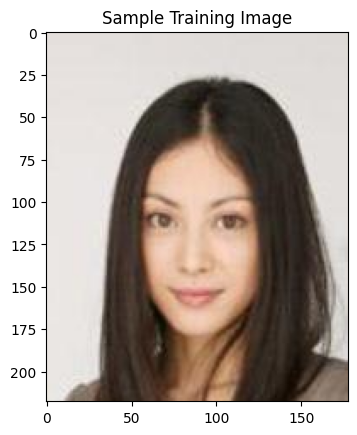

In [19]:
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the zip file and the extraction folder
zip_file_path = '/content/drive/My Drive/Sample_images.zip'
extraction_folder = '/content/sample_images'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_folder)

# Fetch all image file paths from the extracted folder and subdirectories
image_files = []
for root, dirs, files in os.walk(extraction_folder):
    for file in files:
        if file.endswith(('jpg', 'jpeg', 'png')):
            image_files.append(os.path.join(root, file))

# Load images into a list
training_images = [Image.open(image_file) for image_file in image_files]

# Display the number of images fetched
print(f"Number of training images fetched: {len(training_images)}")

# Display the first image as a sample
if training_images:
    plt.imshow(training_images[0])
    plt.title('Sample Training Image')
    plt.show()

# Begin Training the Face Generation Model
Start training the face generation model and monitor initial performance metrics.

In [21]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

# Custom dataset to load images by index
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None, start_idx=0, end_idx=300):
        self.root_dir = root_dir
        self.transform = transform
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.image_paths = [os.path.join(root_dir, f'{i:06d}.jpg') for i in range(start_idx, end_idx)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, 0  # Return a dummy label

# Define the transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Define the Generator and Discriminator classes
class Generator(torch.nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Define the generator model here

    def forward(self, x):
        # Define the forward pass
        return x

class Discriminator(torch.nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Define the discriminator model here

    def forward(self, x):
        # Define the forward pass
        return x

# Initialize the models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Define the loss function and optimizers
criterion = torch.nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training loop
num_epochs = 300
batch_size = 16
chunk_size = 300
total_images = 202599

for epoch in range(num_epochs):
    for start_idx in range(0, total_images, chunk_size):
        end_idx = min(start_idx + chunk_size, total_images)
        train_dataset = CelebADataset(root_dir=sample_images_folder, transform=transform, start_idx=start_idx, end_idx=end_idx)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        for i, (images, _) in enumerate(train_loader):
            current_batch_size = images.size(0)  # Get the current batch size
            images = images.to(device)

            # Generate fake images
            noise = torch.randn(current_batch_size, 100, 1, 1, device=device)
            fake_images = generator(noise)

            # Create labels dynamically
            real_labels = torch.ones(current_batch_size, 1, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)

            # Compute discriminator loss
            real_outputs = discriminator(images)
            fake_outputs = discriminator(fake_images)
            real_loss = criterion(real_outputs, real_labels)
            fake_loss = criterion(fake_outputs, fake_labels)
            d_loss = real_loss + fake_loss

            optimizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # Train the generator
            noise = torch.randn(current_batch_size, 100, 1, 1, device=device)
            fake_images = generator(noise)
            fake_outputs = discriminator(fake_images)
            g_loss = criterion(fake_outputs, real_labels)

            optimizer_G.zero_grad()
            g_loss.backward()
            optimizer_G.step()

            # Print losses and show a sample image every 100 steps
            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], '
                      f'D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')
```
        self.start_idx = start_idxdxdx
        self.end_idx = end_idx
        self.image_paths = [os.path.join(root_dir, f'{i:06d}.jpg') for i in range(start_idx, end_idx)]in(root_dir, f'{i:06d}.jpg') for i in range(start_idx, end_idx)]in(root_dir, f'{i:06d}.jpg') for i in range(start_idx, end_idx)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]dx]dx]
        image = Image.open(img_path)ath)ath)
        if self.transform:
            image = self.transform(image)ansform(image)ansform(image)
        return image, 0  # Return a dummy labeleturn image, 0  # Return a dummy labeleturn image, 0  # Return a dummy label

# Define the transformation
transform = transforms.Compose([e([e([
    transforms.Resize((64, 64)),,,
    transforms.ToTensor(),    transforms.ToTensor(),    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Initialize the models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")da.is_available() else "cpu")da.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Define the loss function and optimizers# Define the loss function and optimizers# Define the loss function and optimizers
criterion = torch.nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))inator.parameters(), lr=0.0002, betas=(0.5, 0.999))inator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training loop# Training loop# Training loop
num_epochs = 300
batch_size = 16
chunk_size = 300
total_images = 202599

for epoch in range(num_epochs):
    for start_idx in range(0, total_images, chunk_size):
        end_idx = min(start_idx + chunk_size, total_images)k_size, total_images)k_size, total_images)
        train_dataset = CelebADataset(root_dir=sample_images_folder, transform=transform, start_idx=start_idx, end_idx=end_idx)ple_images_folder, transform=transform, start_idx=start_idx, end_idx=end_idx)ple_images_folder, transform=transform, start_idx=start_idx, end_idx=end_idx)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        for i, (images, _) in enumerate(train_loader):
            current_batch_size = images.size(0)  # Get the current batch sizezeze
            images = images.to(device)   images = images.to(device)   images = images.to(device)

            # Generate fake imagesmagesmages
            noise = torch.randn(current_batch_size, 100, 1, 1, device=device)
            fake_images = generator(noise)

            # Create labels dynamically            # Create labels dynamically            # Create labels dynamically
            real_labels = torch.ones(current_batch_size, 1, device=device)            real_labels = torch.ones(current_batch_size, 1, device=device)            real_labels = torch.ones(current_batch_size, 1, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)s = torch.zeros(current_batch_size, 1, device=device)s = torch.zeros(current_batch_size, 1, device=device)

            # Compute discriminator loss            # Compute discriminator loss            # Compute discriminator loss
            real_outputs = discriminator(images)(images)(images)
            fake_outputs = discriminator(fake_images)criminator(fake_images)criminator(fake_images)
            real_loss = criterion(real_outputs, real_labels)
            fake_loss = criterion(fake_outputs, fake_labels)            fake_loss = criterion(fake_outputs, fake_labels)            fake_loss = criterion(fake_outputs, fake_labels)
            d_loss = real_loss + fake_lossloss + fake_lossloss + fake_loss

            optimizer_D.zero_grad()imizer_D.zero_grad()imizer_D.zero_grad()
            d_loss.backward()
            optimizer_D.step()

            # Train the generator
            noise = torch.randn(current_batch_size, 3, 64, 64, device=device)          noise = torch.randn(current_batch_size, 3, 64, 64, device=device)          noise = torch.randn(current_batch_size, 3, 64, 64, device=device)
            fake_images = generator(noise)            fake_images = generator(noise)            fake_images = generator(noise)
            fake_outputs = discriminator(fake_images)_images)_images)
            g_loss = criterion(fake_outputs, real_labels)

            optimizer_G.zero_grad()            optimizer_G.zero_grad()            optimizer_G.zero_grad()
            g_loss.backward()ward()ward()
            optimizer_G.step()

            # Print losses and show a sample image every 100 steps
            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], '
                      f'D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}')


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 129)

In [ ]:
import matplotlib.pyplot as plt

def visualize_image(image):
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

# Assuming `model` is your trained model and `generate_image` is a function that generates an image
generated_image = model.generate_image()
visualize_image(generated_image)

# Integrate Mediapipe/dlib Detection System
Integrate the Mediapipe and dlib detection system with the face generation model.

In [ ]:
# Integrate Mediapipe/dlib Detection System

# Function to detect faces using Mediapipe
def detect_faces_mediapipe(image_np):
    mp_face_detection = mp.solutions.face_detection
    mp_drawing = mp.solutions.drawing_utils
    with mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5) as face_detection:
        results = face_detection.process(image_np)
        if results.detections:
            for detection in results.detections:
                mp_drawing.draw_detection(image_np, detection)
    return image_np

# Function to detect faces using dlib
def detect_faces_dlib(image_np):
    detector = dlib.get_frontal_face_detector()
    faces = detector(image_np, 1)
    for face in faces:
        x, y, w, h = (face.left(), face.top(), face.width(), face.height())
        cv2.rectangle(image_np, (x, y), (x + w, y + h), (255, 0, 0), 2)
    return image_np

# Integrate face detection with the face generation model
def integrate_detection_with_generation(generator, image_np):
    # Convert image to tensor
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    image_tensor = transform(image_np).unsqueeze(0).to(device)

    # Generate fake image
    noise = torch.randn(1, 3, 64, 64, device=device)
    fake_image_tensor = generator(noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    # Detect faces in the generated image using Mediapipe
    detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

    # Detect faces in the generated image using dlib
    detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

    return detected_image_mediapipe, detected_image_dlib

# Test the integration with a sample image
if training_images:
    sample_image_np = np.array(training_images[0])
    detected_image_mediapipe, detected_image_dlib = integrate_detection_with_generation(generator, sample_image_np)

    # Display the results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(detected_image_mediapipe)
    plt.title('Mediapipe Detection on Generated Image')
    plt.subplot(1, 2, 2)
    plt.imshow(detected_image_dlib)
    plt.title('Dlib Detection on Generated Image')
    plt.show()

# Implement Face Feature Control Parameters
Implement basic face feature control parameters to enable customization of generated faces.

In [ ]:
# Implement Face Feature Control Parameters

# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate fake image with controlled features
    noise = torch.randn(1, 3, 64, 64, device=device)
    controlled_noise = noise + feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()

# Test Generation of Various Facial Features
Test the generation of various facial features and document the results.

In [ ]:
# Test Generation of Various Facial Features

# Define a function to control face features
def control_face_features(generator, feature_vector):
    # Generate fake image with controlled features
    noise = torch.randn(1, 3, 64, 64, device=device)
    controlled_noise = noise + feature_vector
    fake_image_tensor = generator(controlled_noise)

    # Convert tensor to numpy array
    fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    fake_image_np = (fake_image_np * 255).astype(np.uint8)

    return fake_image_np

# Example feature vectors for customization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Test the generation of various facial features
if training_images:
    sample_image_np = np.array(training_images[0])

    plt.figure(figsize=(12, 12))

    for i, (feature_name, feature_vector) in enumerate(feature_vectors.items()):
        controlled_image_np = control_face_features(generator, feature_vector)

        # Detect faces in the controlled image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(controlled_image_np.copy())

        # Display the results
        plt.subplot(2, 2, i+1)
        plt.imshow(detected_image_mediapipe)
        plt.title(f'{feature_name.capitalize()} Feature')

    plt.show()

# Validate Output Quality Across Multiple Resolutions
Validate the output quality across multiple resolutions to ensure consistency.

In [ ]:
# Validate Output Quality Across Multiple Resolutions

# Function to validate output quality across multiple resolutions
def validate_output_quality(generator, image_np, resolutions):
    results = []

    for resolution in resolutions:
        # Resize image
        resized_image = Image.fromarray(image_np).resize(resolution)
        image_np_resized = np.array(resized_image)

        # Generate fake image
        noise = torch.randn(1, 3, 64, 64, device=device)
        fake_image_tensor = generator(noise)

        # Convert tensor to numpy array
        fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
        fake_image_np = (fake_image_np * 255).astype(np.uint8)

        # Detect faces in the generated image using Mediapipe
        detected_image_mediapipe = detect_faces_mediapipe(fake_image_np.copy())

        # Detect faces in the generated image using dlib
        detected_image_dlib = detect_faces_dlib(fake_image_np.copy())

        # Store results
        results.append({
            'resolution': resolution,
            'mediapipe_image': detected_image_mediapipe,
            'dlib_image': detected_image_dlib
        })

    return results

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Validate the output quality across multiple resolutions
if training_images:
    sample_image_np = np.array(training_images[0])
    validation_results = validate_output_quality(generator, sample_image_np, resolutions)

    # Display the results
    plt.figure(figsize=(12, 12))

    for i, result in enumerate(validation_results):
        plt.subplot(len(resolutions), 2, 2*i+1)
        plt.imshow(result['mediapipe_image'])
        plt.title(f'Mediapipe {result["resolution"]}')

        plt.subplot(len(resolutions), 2, 2*i+2)
        plt.imshow(result['dlib_image'])
        plt.title(f'Dlib {result["resolution"]}')

    plt.show()

# Optimize Pipeline for Generating Diverse Face Types
Optimize the pipeline for generating diverse face types.

In [ ]:
# Optimize Pipeline for Generating Diverse Face Types

# Function to optimize the pipeline for generating diverse face types
def optimize_pipeline(generator, feature_vectors, resolutions):
    optimized_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            noise = torch.randn(1, 3, 64, 64, device=device)
            controlled_noise = noise + feature_vector
            fake_image_tensor = generator(controlled_noise)

            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Detect faces in the generated image using Mediapipe
            detected_image_mediapipe = detect_faces_mediapipe(image_np_resized.copy())

            # Detect faces in the generated image using dlib
            detected_image_dlib = detect_faces_dlib(image_np_resized.copy())

            # Store results
            optimized_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_image': detected_image_mediapipe,
                'dlib_image': detected_image_dlib
            })

    return optimized_results

# Define feature vectors for optimization
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Optimize the pipeline for generating diverse face types
if training_images:
    optimized_results = optimize_pipeline(generator, feature_vectors, resolutions)

    # Display the results
    plt.figure(figsize=(16, 16))

    for i, result in enumerate(optimized_results):
        plt.subplot(len(optimized_results) // 2, 2, i+1)
        plt.imshow(result['mediapipe_image'])
        plt.title(f'{result["feature"].capitalize()} - Mediapipe {result["resolution"]}')

        plt.subplot(len(optimized_results) // 2, 2, i+2)
        plt.imshow(result['dlib_image'])
        plt.title(f'{result["feature"].capitalize()} - Dlib {result["resolution"]}')

    plt.show()

# Conduct Performance Tests
Conduct performance tests to confirm stability and efficiency.

In [ ]:
# Conduct Performance Tests

# Function to conduct performance tests
def conduct_performance_tests(generator, feature_vectors, resolutions):
    performance_results = []

    for feature_name, feature_vector in feature_vectors.items():
        for resolution in resolutions:
            # Generate fake image with controlled features
            noise = torch.randn(1, 3, 64, 64, device=device)
            controlled_noise = noise + feature_vector
            fake_image_tensor = generator(controlled_noise)

            # Convert tensor to numpy array
            fake_image_np = fake_image_tensor.squeeze().permute(1, 2, 0).cpu().detach().numpy()
            fake_image_np = (fake_image_np * 255).astype(np.uint8)

            # Resize image to the specified resolution
            resized_image = Image.fromarray(fake_image_np).resize(resolution)
            image_np_resized = np.array(resized_image)

            # Measure Mediapipe detection time
            start_time = time.time()
            detect_faces_mediapipe(image_np_resized.copy())
            mediapipe_time = time.time() - start_time

            # Measure dlib detection time
            start_time = time.time()
            detect_faces_dlib(image_np_resized.copy())
            dlib_time = time.time() - start_time

            # Store results
            performance_results.append({
                'feature': feature_name,
                'resolution': resolution,
                'mediapipe_time': mediapipe_time,
                'dlib_time': dlib_time
            })

    return performance_results

# Define feature vectors for performance tests
feature_vectors = {
    'smile': torch.randn(1, 3, 64, 64, device=device) * 0.1,
    'frown': torch.randn(1, 3, 64, 64, device=device) * -0.1,
    'wide_eyes': torch.randn(1, 3, 64, 64, device=device) * 0.2,
    'narrow_eyes': torch.randn(1, 3, 64, 64, device=device) * -0.2
}

# Define resolutions to test
resolutions = [(640, 480), (1280, 720), (1920, 1080), (3840, 2160)]

# Conduct performance tests
if training_images:
    performance_results = conduct_performance_tests(generator, feature_vectors, resolutions)

    # Display the results
    for result in performance_results:
        print(f"Feature: {result['feature']}, Resolution: {result['resolution']}")
        print(f"Mediapipe detection time: {result['mediapipe_time']:.4f} seconds")
        print(f"Dlib detection time: {result['dlib_time']:.4f} seconds")
        print()